# Agricultural Drought — Report Visualisations

Loads cached outputs from the hazard and risk assessment notebooks.
Run both notebooks before executing this script.

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import rasterio
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path

# --- Configuration -----------------------------------------------------------
SHAPEFILE_PATH = Path(
    r'C:\Users\dauzo\Models\crabook-kazakhstan\crabook'
    r'\KAZ_BORDER_VERSION_1\LVL3\SHP_LVL3\KAZ_OSM_BORDER_LVL3.shp'
)  # <-- update to your local shapefile path
workflow_dir = 'agriculture_workflow'
data_dir     = os.path.join(workflow_dir, 'data')
results_dir  = os.path.join(workflow_dir, 'results')
spam_folder  = os.path.join(data_dir, 'spam2020V2r0_global_production')
FIG_DIR      = Path('./report_figures/agricultural_drought')
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Must match settings used in the hazard and risk notebooks
region_name = 'Kazakhstan'   # <-- update if a specific oblast was used
region_id   = 'KAZ'         # <-- update accordingly
crop_list   = ['wheat', 'maize']   # <-- update to match hazard notebook crop_list
spam_list   = ['WHEA', 'MAIZ']     # <-- update to match risk notebook spam_list

plt.rcParams.update({'font.size': 9, 'figure.dpi': 150, 'axes.titlesize': 9})
print('Configuration ready.')

Configuration ready.


In [2]:
# Load hazard outputs
yield_loss = np.load(os.path.join(results_dir, f'{region_name}_yield_loss_NUMPY.npy'))
hazard_df  = pd.read_csv(os.path.join(results_dir, f'{region_name}_yield_loss_SPREADSHEET.csv'))

rcp_label    = hazard_df['rcp'][0]
ystart       = int(hazard_df['start_year'][0])
yend         = int(hazard_df['end_year'][0])
fields_shape = yield_loss.shape[:2]   # (nlat, nlon)
coords_11    = np.stack((hazard_df['lon'].to_numpy(), hazard_df['lat'].to_numpy()), axis=1)

# 1-D lat/lon arrays for imshow extent (ISIMIP3b regular 0.5 deg grid)
lons_1d = np.sort(np.unique(np.round(hazard_df['lon'].values, 3)))
lats_1d = np.sort(np.unique(np.round(hazard_df['lat'].values, 3)))
dlon = float(lons_1d[1] - lons_1d[0]) if len(lons_1d) > 1 else 0.5
dlat = float(lats_1d[1] - lats_1d[0]) if len(lats_1d) > 1 else 0.5
# Pixel edges for imshow extent: [left, right, bottom, top]
img_extent = [lons_1d[0] - dlon/2, lons_1d[-1] + dlon/2,
              lats_1d[0] - dlat/2, lats_1d[-1] + dlat/2]
# Map view extent (slightly wider than data)
map_extent = [img_extent[0] - 1, img_extent[1] + 1,
              img_extent[2] - 1, img_extent[3] + 1]

# Load first NetCDF for AWC, precip, ET0
nc_files = sorted(glob.glob(os.path.join(results_dir, f'agridrought_hazard_{region_id}_*.nc')))
ds0      = xr.open_dataset(nc_files[0]) if nc_files else None
awc_arr    = ds0['AWC'].to_numpy()    if ds0 is not None else None
precip_arr = ds0['precip'].to_numpy() if ds0 is not None else None
et0_arr    = ds0['ET0'].to_numpy()    if ds0 is not None else None

# Kazakhstan dissolved boundary for map overlays
kaz_gdf      = gpd.read_file(SHAPEFILE_PATH).to_crs(epsg=4326)
kaz_boundary = kaz_gdf.dissolve()

print(f'Yield loss shape: {yield_loss.shape}  crops={crop_list}')
print(f'Grid: {fields_shape[0]} lat x {fields_shape[1]} lon')
print(f'Img extent: {img_extent}')
print(f'NetCDF files found: {len(nc_files)}')
print(f'Loaded: scenario={rcp_label}  period={ystart}-{yend}')

Yield loss shape: (32, 84, 2)  crops=['wheat', 'maize']
Grid: 32 lat x 84 lon
Img extent: [np.float64(46.0), np.float64(88.0), np.float64(40.0), np.float64(56.0)]
NetCDF files found: 1
Loaded: scenario=ssp126  period=2046-2050


In [3]:
# Helpers

def setup_ax(ax, title=''):
    """Apply standard cartopy configuration to an existing axes."""
    ax.set_extent(map_extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, linestyle=':')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    if title:
        ax.set_title(title, fontsize=8, fontweight='bold')


def draw_boundary(ax):
    """Overlay Kazakhstan boundary (multi-part safe)."""
    from shapely.geometry import MultiPolygon
    for geom in kaz_boundary.geometry:
        parts = list(geom.geoms) if isinstance(geom, MultiPolygon) else [geom]
        for g in parts:
            xs, ys = g.exterior.xy
            ax.plot(xs, ys, transform=ccrs.PlateCarree(),
                    color='navy', linewidth=1.0, zorder=4)


def imshow_kaz(ax, data, cmap, vmin, vmax):
    """Display a (nlat, nlon) array on a pre-configured cartopy axes."""
    return ax.imshow(
        data, origin='lower', extent=img_extent,
        cmap=cmap, vmin=vmin, vmax=vmax,
        transform=ccrs.PlateCarree(), interpolation='nearest', zorder=2
    )

## Figure 1 — Soil available water capacity

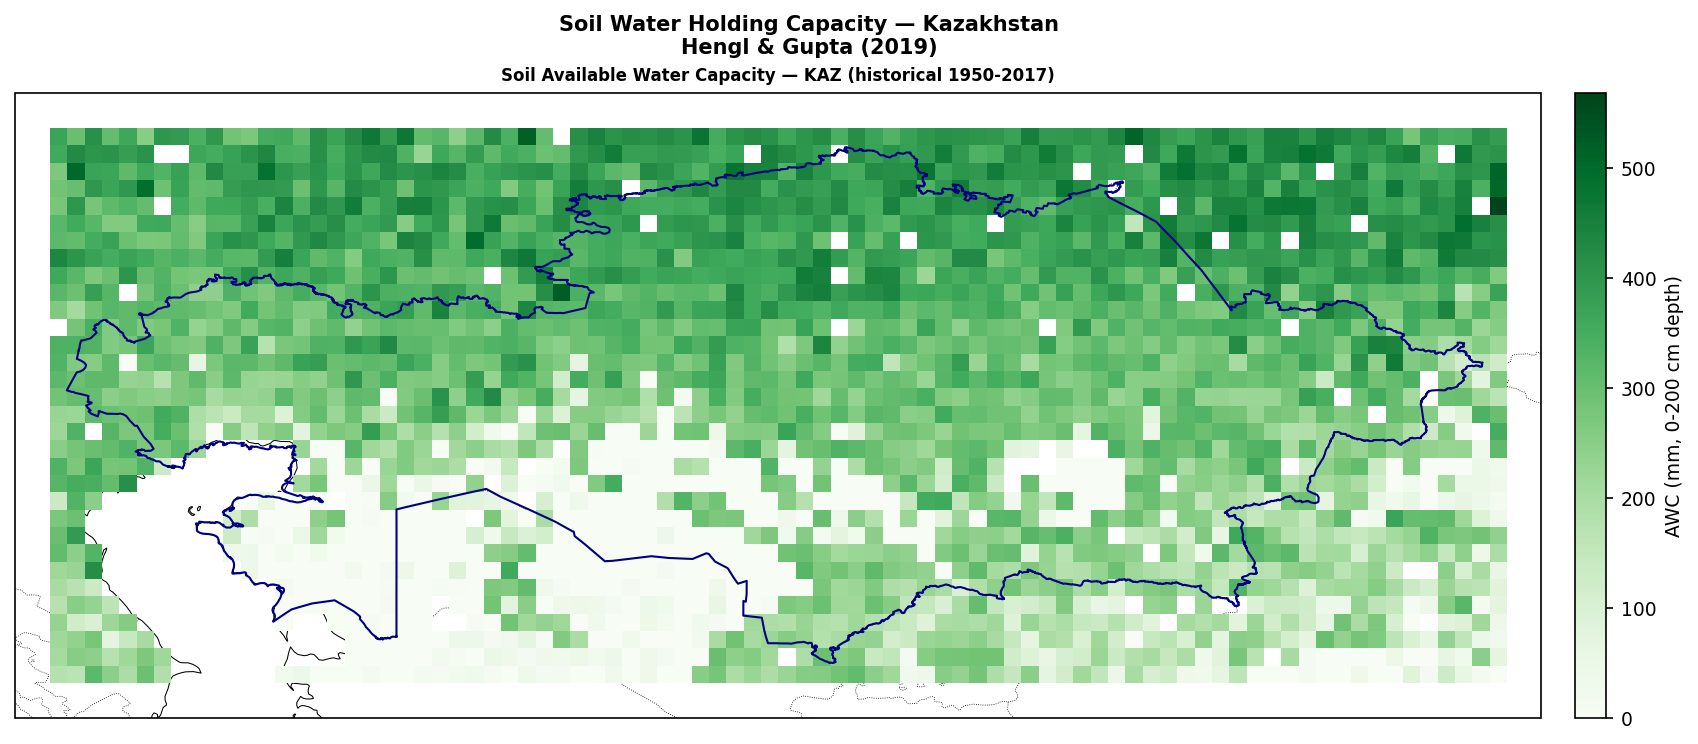

Figure 1 saved.


In [4]:
if awc_arr is not None:
    fig, ax = plt.subplots(1, 1, figsize=(12, 5),
                           subplot_kw={'projection': ccrs.PlateCarree()})
    setup_ax(ax, f'Soil Available Water Capacity — {region_id} (historical 1950-2017)')
    im = imshow_kaz(ax, awc_arr, 'Greens', 0, np.nanmax(awc_arr))
    draw_boundary(ax)
    plt.colorbar(im, ax=ax, orientation='vertical', fraction=0.025, pad=0.02,
                 label='AWC (mm, 0-200 cm depth)')
    fig.suptitle('Soil Water Holding Capacity — Kazakhstan\nHengl & Gupta (2019)',
                 fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig01_AWC.png', bbox_inches='tight')
    plt.show()
    print('Figure 1 saved.')
else:
    print('No NetCDF found — skipping Figure 1.')

## Figure 2 — Annual mean precipitation and reference ET0

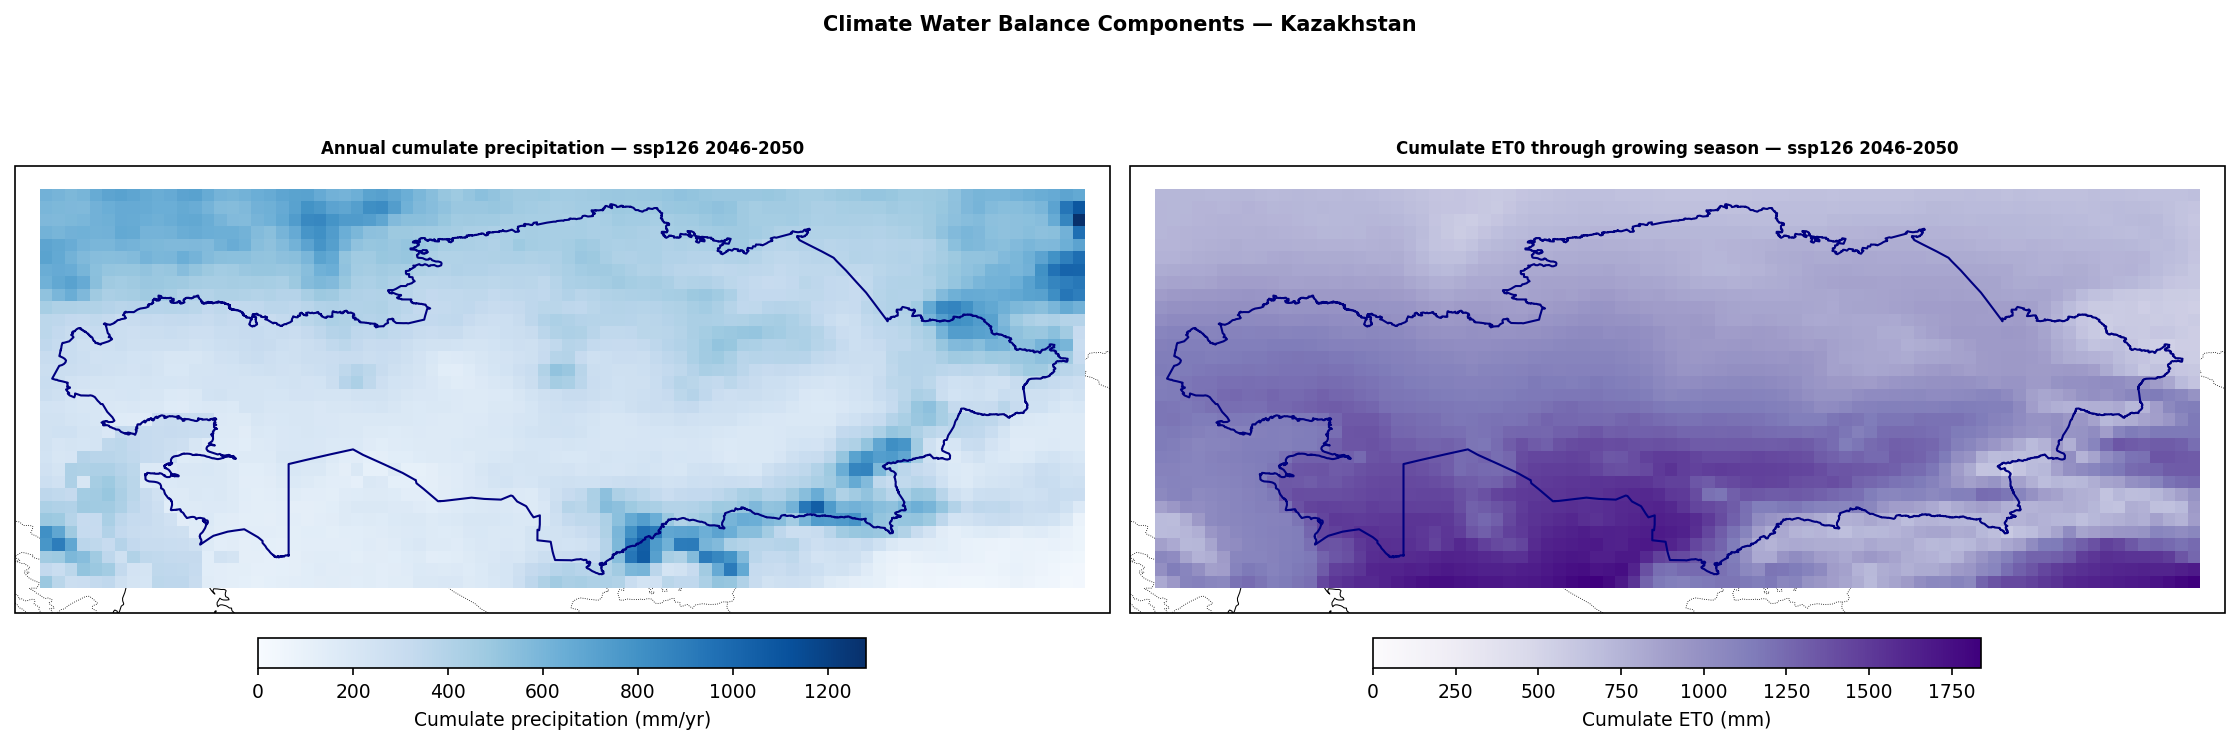

Figure 2 saved.


In [5]:
if precip_arr is not None and et0_arr is not None:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5),
                             subplot_kw={'projection': ccrs.PlateCarree()})

    setup_ax(axes[0], f'Annual cumulate precipitation — {rcp_label} {ystart}-{yend}')
    im0 = imshow_kaz(axes[0], precip_arr, 'Blues', 0, np.nanmax(precip_arr))
    draw_boundary(axes[0])
    plt.colorbar(im0, ax=axes[0], orientation='horizontal', fraction=0.05, pad=0.04,
                 label='Cumulate precipitation (mm/yr)')

    setup_ax(axes[1], f'Cumulate ET0 through growing season — {rcp_label} {ystart}-{yend}')
    im1 = imshow_kaz(axes[1], et0_arr, 'Purples', 0, np.nanmax(et0_arr))
    draw_boundary(axes[1])
    plt.colorbar(im1, ax=axes[1], orientation='horizontal', fraction=0.05, pad=0.04,
                 label='Cumulate ET0 (mm)')

    fig.suptitle('Climate Water Balance Components — Kazakhstan', fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig02_precip_ET0.png', bbox_inches='tight')
    plt.show()
    print('Figure 2 saved.')

## Figure 3 — Yield loss maps per crop

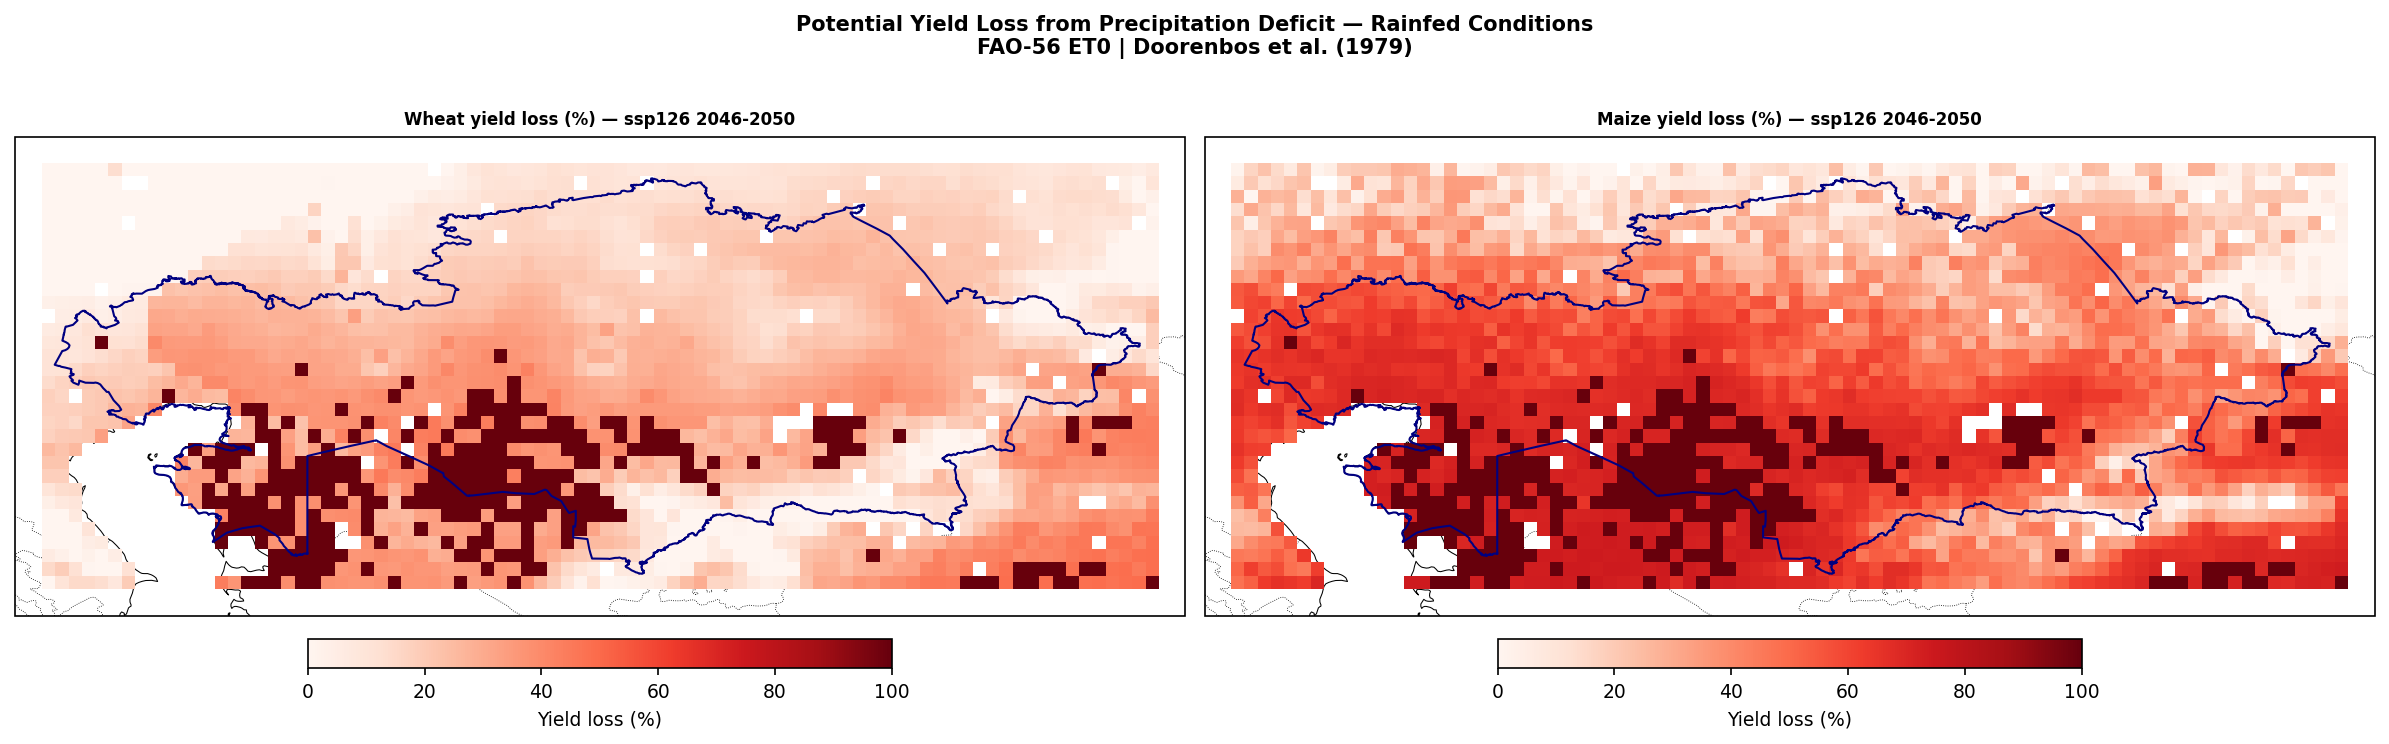

Figure 3 saved.


In [6]:
n_crops = yield_loss.shape[2]
fig, axes = plt.subplots(1, n_crops, figsize=(8 * n_crops, 5),
                         subplot_kw={'projection': ccrs.PlateCarree()})
axes = [axes] if n_crops == 1 else list(axes)

for a, (ax, crop) in enumerate(zip(axes, crop_list)):
    setup_ax(ax, f'{crop.title()} yield loss (%) — {rcp_label} {ystart}-{yend}')
    im = imshow_kaz(ax, yield_loss[:, :, a], 'Reds', 0, 100)
    draw_boundary(ax)
    plt.colorbar(im, ax=ax, orientation='horizontal', fraction=0.05, pad=0.04,
                 label='Yield loss (%)')

fig.suptitle('Potential Yield Loss from Precipitation Deficit — Rainfed Conditions\n'
             'FAO-56 ET0 | Doorenbos et al. (1979)',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig03_yield_loss_maps.png', bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

## Figure 4 — Yield loss vs available water capacity scatter

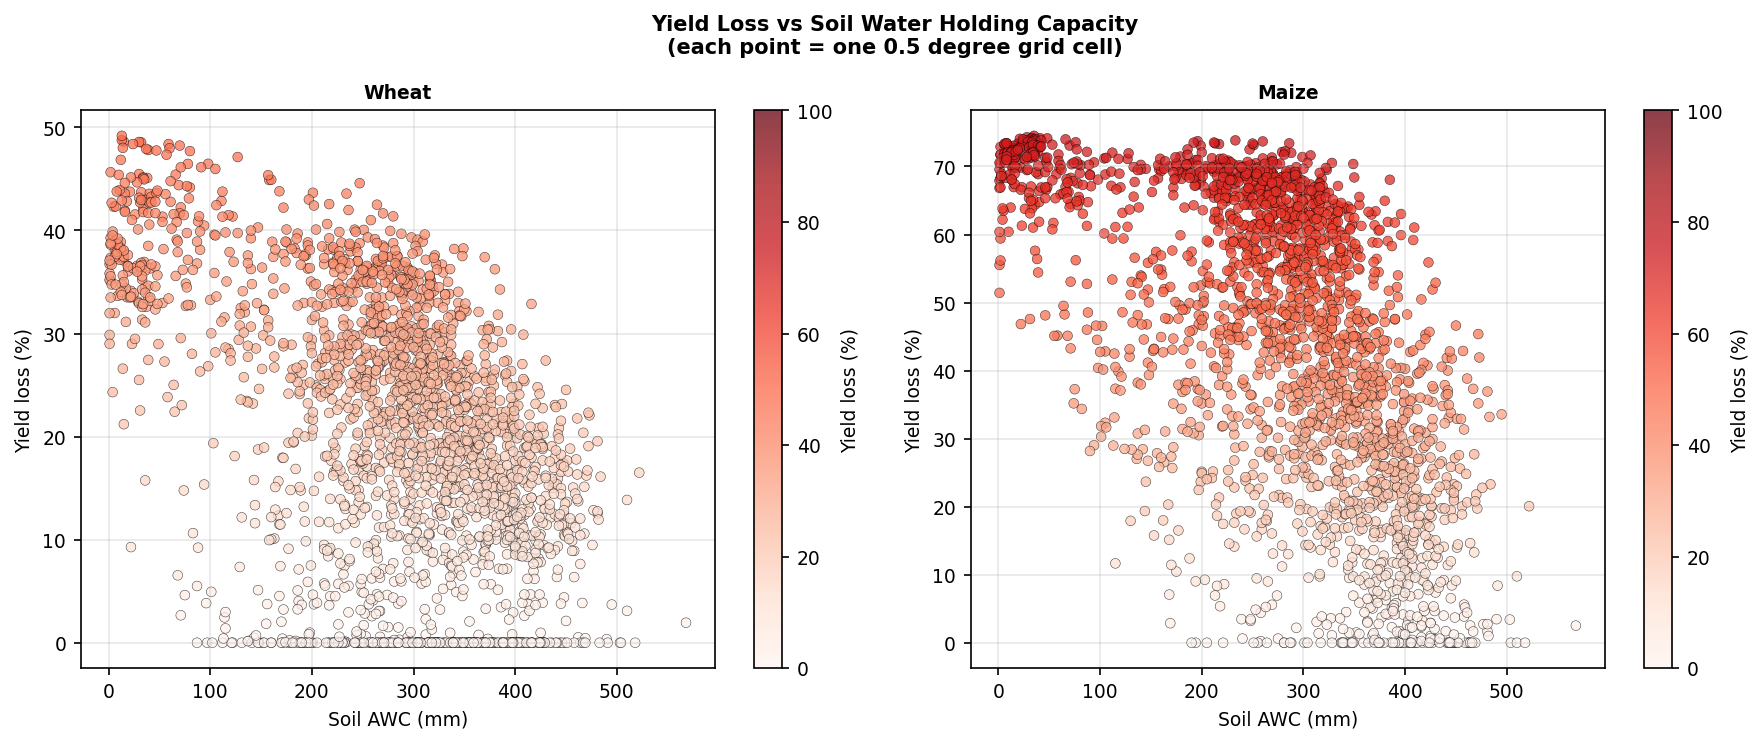

Figure 4 saved.


In [7]:
fig, axes = plt.subplots(1, n_crops, figsize=(6 * n_crops, 5))
axes = [axes] if n_crops == 1 else list(axes)
colors_crops = ['#e07070', '#70a0d0', '#70c070', '#d0a870']

for a, (ax, crop) in enumerate(zip(axes, crop_list)):
    yl_f   = yield_loss[:, :, a].ravel()
    awc_f  = awc_arr.ravel() if awc_arr is not None else np.full_like(yl_f, np.nan)
    mask   = np.isfinite(yl_f) & np.isfinite(awc_f) & (awc_f > 0)
    sc = ax.scatter(awc_f[mask], yl_f[mask],
                    c=yl_f[mask], cmap='Reds', vmin=0, vmax=100,
                    s=22, alpha=0.75, edgecolors='black', linewidths=0.25)
    plt.colorbar(sc, ax=ax, label='Yield loss (%)')
    ax.set_xlabel('Soil AWC (mm)')
    ax.set_ylabel('Yield loss (%)')
    ax.set_title(f'{crop.title()}', fontweight='bold')
    ax.grid(alpha=0.3)

fig.suptitle('Yield Loss vs Soil Water Holding Capacity\n(each point = one 0.5 degree grid cell)',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig04_yield_loss_vs_AWC.png', bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

## Figure 5 — Scenario or model comparison

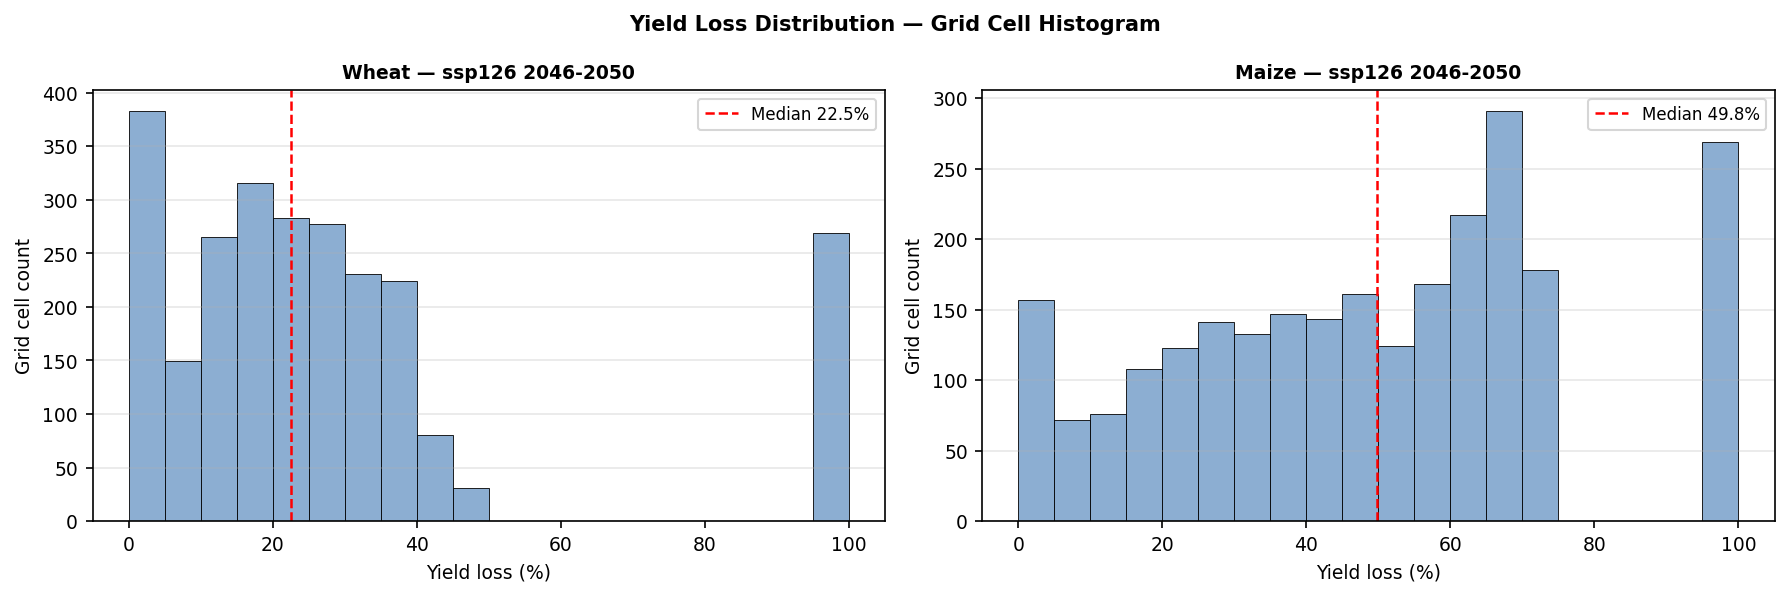

Figure 5 saved.


In [8]:
if len(nc_files) > 1:
    run_data = {}
    for f in nc_files:
        ds  = xr.open_dataset(f)
        key = (f'{ds.attrs.get("scenario","?")} '
               f'{str(ds.attrs.get("model","?"))[:10]}')
        run_data[key] = ds['yield_loss'].to_numpy()   # shape (n_crops, nlat, nlon)
        ds.close()

    fig, axes = plt.subplots(1, n_crops, figsize=(7 * n_crops, 5))
    axes = [axes] if n_crops == 1 else list(axes)

    for a, (ax, crop) in enumerate(zip(axes, crop_list)):
        labels = list(run_data.keys())
        vals   = [run_data[k][a].ravel() for k in labels]
        vals   = [v[np.isfinite(v)] for v in vals]
        parts  = ax.violinplot(vals, positions=range(len(labels)),
                               showmedians=True, widths=0.65)
        parts['cmedians'].set_color('black')
        for pc in parts['bodies']:
            pc.set_facecolor('#8CAED2')
            pc.set_alpha(0.75)
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, fontsize=7, rotation=15, ha='right')
        ax.set_ylabel('Yield loss (%)')
        ax.set_title(f'{crop.title()}', fontweight='bold')
        ax.grid(axis='y', alpha=0.3)

    fig.suptitle('Yield Loss Distribution by Scenario / Model Run',
                 fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig05_scenario_comparison.png', bbox_inches='tight')
    plt.show()

else:
    fig, axes = plt.subplots(1, n_crops, figsize=(6 * n_crops, 4))
    axes = [axes] if n_crops == 1 else list(axes)

    for a, (ax, crop) in enumerate(zip(axes, crop_list)):
        vals = yield_loss[:, :, a].ravel()
        vals = vals[np.isfinite(vals)]
        ax.hist(vals, bins=20, color='#8CAED2', edgecolor='black', linewidth=0.4)
        ax.axvline(np.median(vals), color='red', linestyle='--', linewidth=1.2,
                   label=f'Median {np.median(vals):.1f}%')
        ax.set_xlabel('Yield loss (%)')
        ax.set_ylabel('Grid cell count')
        ax.set_title(f'{crop.title()} — {rcp_label} {ystart}-{yend}', fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(axis='y', alpha=0.3)

    fig.suptitle('Yield Loss Distribution — Grid Cell Histogram', fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig05_yield_loss_histogram.png', bbox_inches='tight')
    plt.show()

print('Figure 5 saved.')

## Figure 6 — Revenue loss map

C:\Users\dauzo\AppData\Local\Temp\ipykernel_26804\4059117869.py:33: RuntimeWarning: invalid value encountered in divide
  crop_frac        = crops_spam / spam_sum[:, :, None]


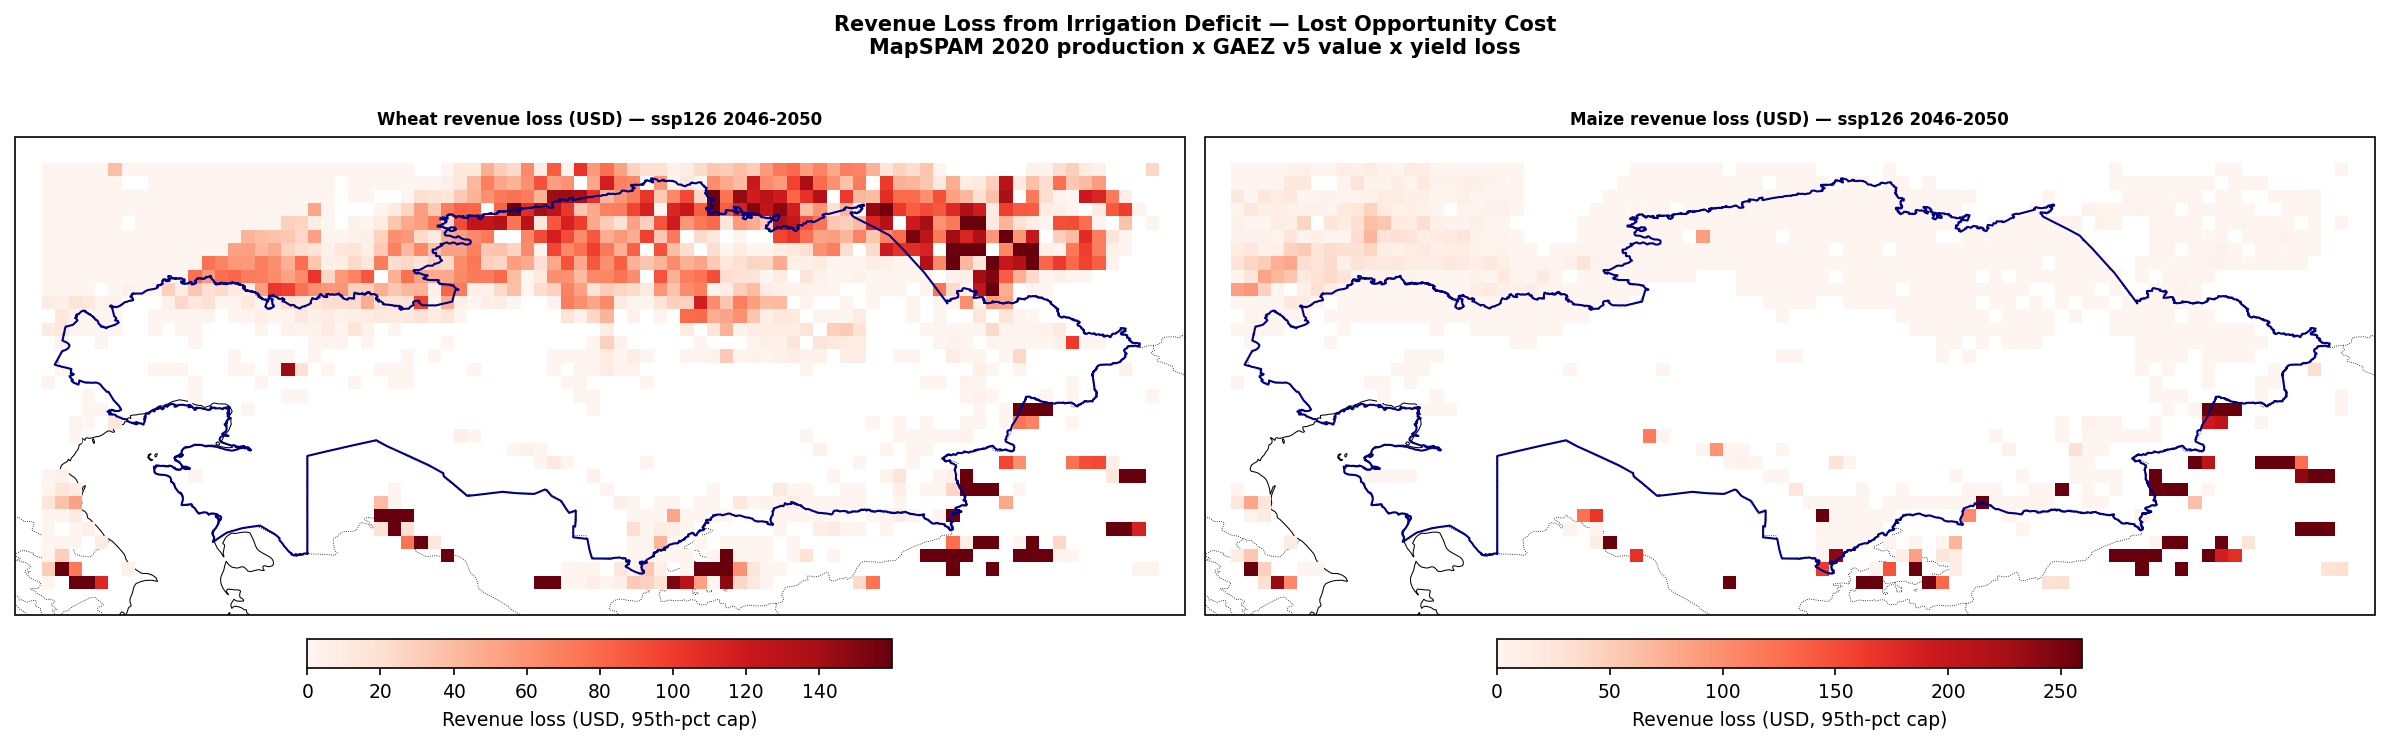

Figure 6 saved.


In [9]:
crop_value_path = os.path.join(data_dir, 'GAEZ-V5.RES06-VAL.ALL.WST.tif')
revenue_loss_usd = None

if os.path.exists(spam_folder) and os.path.exists(crop_value_path):
    crops_spam = np.empty((*fields_shape, len(spam_list)), dtype=np.float64)
    for a, code in enumerate(spam_list):
        tif = next((f for f in os.listdir(spam_folder)
                    if code in f and f.endswith('.tif')), None)
        if tif is None:
            print(f'MapSPAM file not found for {code}.')
            crops_spam[:, :, a] = np.nan
            continue
        with rasterio.open(os.path.join(spam_folder, tif)) as src:
            crops_spam[:, :, a] = np.reshape(
                [x[0] for x in src.sample(coords_11)], fields_shape)
    crops_spam[crops_spam < 0] = np.nan

    df_all = pd.DataFrame()
    for fname in os.listdir(spam_folder):
        if not fname.endswith('.tif'):
            continue
        with rasterio.open(os.path.join(spam_folder, fname)) as src:
            df_all[fname] = [x[0] for x in src.sample(coords_11)]
    spam_sum = df_all.sum(axis=1).to_numpy(dtype=np.float64)
    spam_sum[spam_sum < 0] = np.nan
    spam_sum = spam_sum.reshape(fields_shape)

    with rasterio.open(crop_value_path) as src:
        val_gaez = np.asarray([x[0] for x in src.sample(coords_11)], dtype=np.float64)
    val_gaez[val_gaez < 0] = np.nan
    val_gaez = val_gaez.reshape(fields_shape)

    crop_frac        = crops_spam / spam_sum[:, :, None]
    rev_per_pixel    = val_gaez[:, :, None] * crop_frac
    revenue_loss_usd = rev_per_pixel * yield_loss / 100.

    fig, axes = plt.subplots(1, n_crops, figsize=(8 * n_crops, 5),
                             subplot_kw={'projection': ccrs.PlateCarree()})
    axes = [axes] if n_crops == 1 else list(axes)

    for a, (ax, crop, code) in enumerate(zip(axes, crop_list, spam_list)):
        rl = revenue_loss_usd[:, :, a]
        setup_ax(ax, f'{crop.title()} revenue loss (USD) — {rcp_label} {ystart}-{yend}')
        vmax_rl = np.nanquantile(rl[rl > 0], 0.95) if np.any(rl > 0) else 1.0
        im = imshow_kaz(ax, rl, 'Reds', 0, vmax_rl)
        draw_boundary(ax)
        plt.colorbar(im, ax=ax, orientation='horizontal', fraction=0.05, pad=0.04,
                     label='Revenue loss (USD, 95th-pct cap)')

    fig.suptitle('Revenue Loss from Irrigation Deficit — Lost Opportunity Cost\n'
                 'MapSPAM 2020 production x GAEZ v5 value x yield loss',
                 fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig06_revenue_loss_maps.png', bbox_inches='tight')
    plt.show()
    print('Figure 6 saved.')
else:
    print('SPAM or GAEZ files not found in data_dir — skipping Figure 6.')
    print('Run the risk assessment notebook first to cache these files.')

## Figure 7 — Irrigation vulnerability

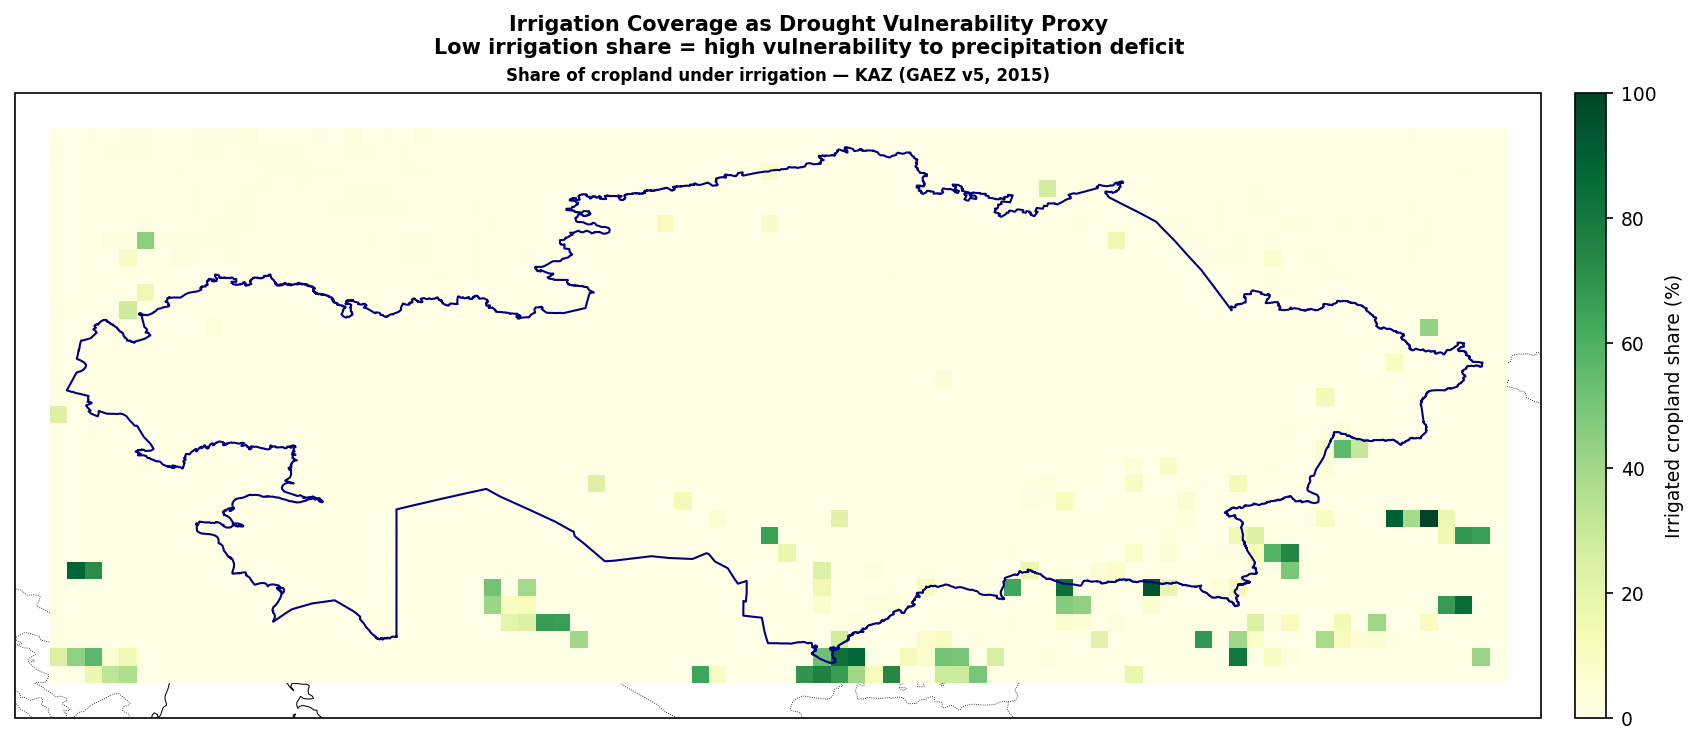

Figure 7 saved.


In [10]:
irr_path  = os.path.join(data_dir, 'GAEZ-V5.LR-IRR.tif')
irr_share = None

if os.path.exists(irr_path):
    with rasterio.open(irr_path) as src:
        irr_share = np.asarray([x[0] for x in src.sample(coords_11)], dtype=np.float64)
    irr_share = irr_share.reshape(fields_shape)
    irr_share[irr_share < 0] = np.nan

    fig, ax = plt.subplots(1, 1, figsize=(12, 5),
                           subplot_kw={'projection': ccrs.PlateCarree()})
    setup_ax(ax, f'Share of cropland under irrigation — {region_id} (GAEZ v5, 2015)')
    im = imshow_kaz(ax, irr_share, 'YlGn', 0, 100)
    draw_boundary(ax)
    plt.colorbar(im, ax=ax, orientation='vertical', fraction=0.025, pad=0.02,
                 label='Irrigated cropland share (%)')
    fig.suptitle('Irrigation Coverage as Drought Vulnerability Proxy\n'
                 'Low irrigation share = high vulnerability to precipitation deficit',
                 fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig07_irrigation_vulnerability.png', bbox_inches='tight')
    plt.show()
    print('Figure 7 saved.')
else:
    print('GAEZ LR-IRR file not found — skipping Figure 7.')

## Figure 8 — Oblast-level mean yield loss

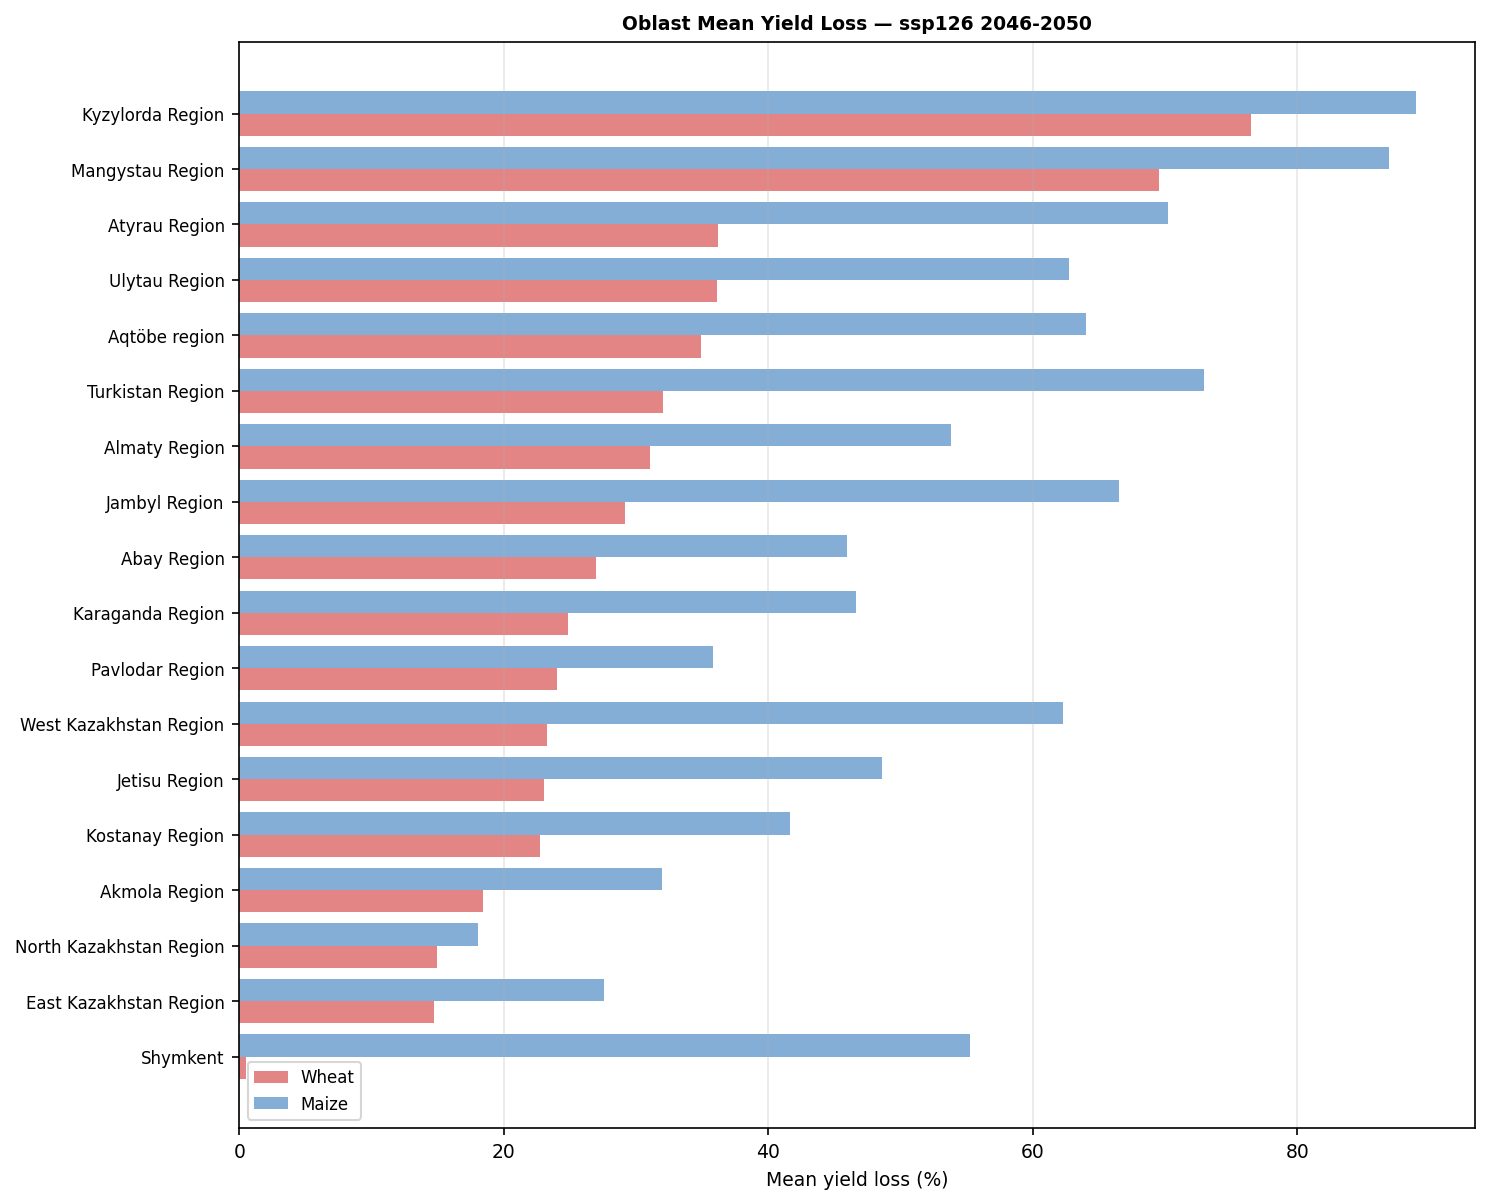

Figure 8 saved.


In [11]:
from shapely.geometry import Point

pts_gdf = gpd.GeoDataFrame(
    hazard_df[['lat', 'lon']].copy(),
    geometry=[Point(x, y) for x, y in zip(hazard_df['lon'], hazard_df['lat'])],
    crs='EPSG:4326'
)
kaz_ob = kaz_gdf[['oblast_en', 'geometry']].copy()
kaz_ob['oblast_en'] = kaz_ob['oblast_en'].str.strip()
joined = gpd.sjoin(pts_gdf, kaz_ob, how='left', predicate='within')

for a, crop in enumerate(crop_list):
    joined[crop] = yield_loss[:, :, a].ravel()

ob_mean = (joined[['oblast_en'] + crop_list]
           .groupby('oblast_en')
           .mean()
           .dropna(how='all')
           .sort_values(crop_list[0]))

fig, ax = plt.subplots(figsize=(10, max(6, len(ob_mean) * 0.45)))
x     = np.arange(len(ob_mean))
width = 0.8 / n_crops
clrs  = ['#e07070', '#70a0d0', '#70c070', '#d0a870']

for a, crop in enumerate(crop_list):
    offset = (a - (n_crops - 1) / 2) * width
    ax.barh(x + offset, ob_mean[crop], height=width,
            color=clrs[a % len(clrs)], label=crop.title(), alpha=0.85)

ax.set_yticks(x)
ax.set_yticklabels(ob_mean.index, fontsize=8)
ax.set_xlabel('Mean yield loss (%)')
ax.set_title(f'Oblast Mean Yield Loss — {rcp_label} {ystart}-{yend}', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig08_oblast_yield_loss.png', bbox_inches='tight')
plt.show()
print('Figure 8 saved.')

## Figure 9 — Summary infographic panel

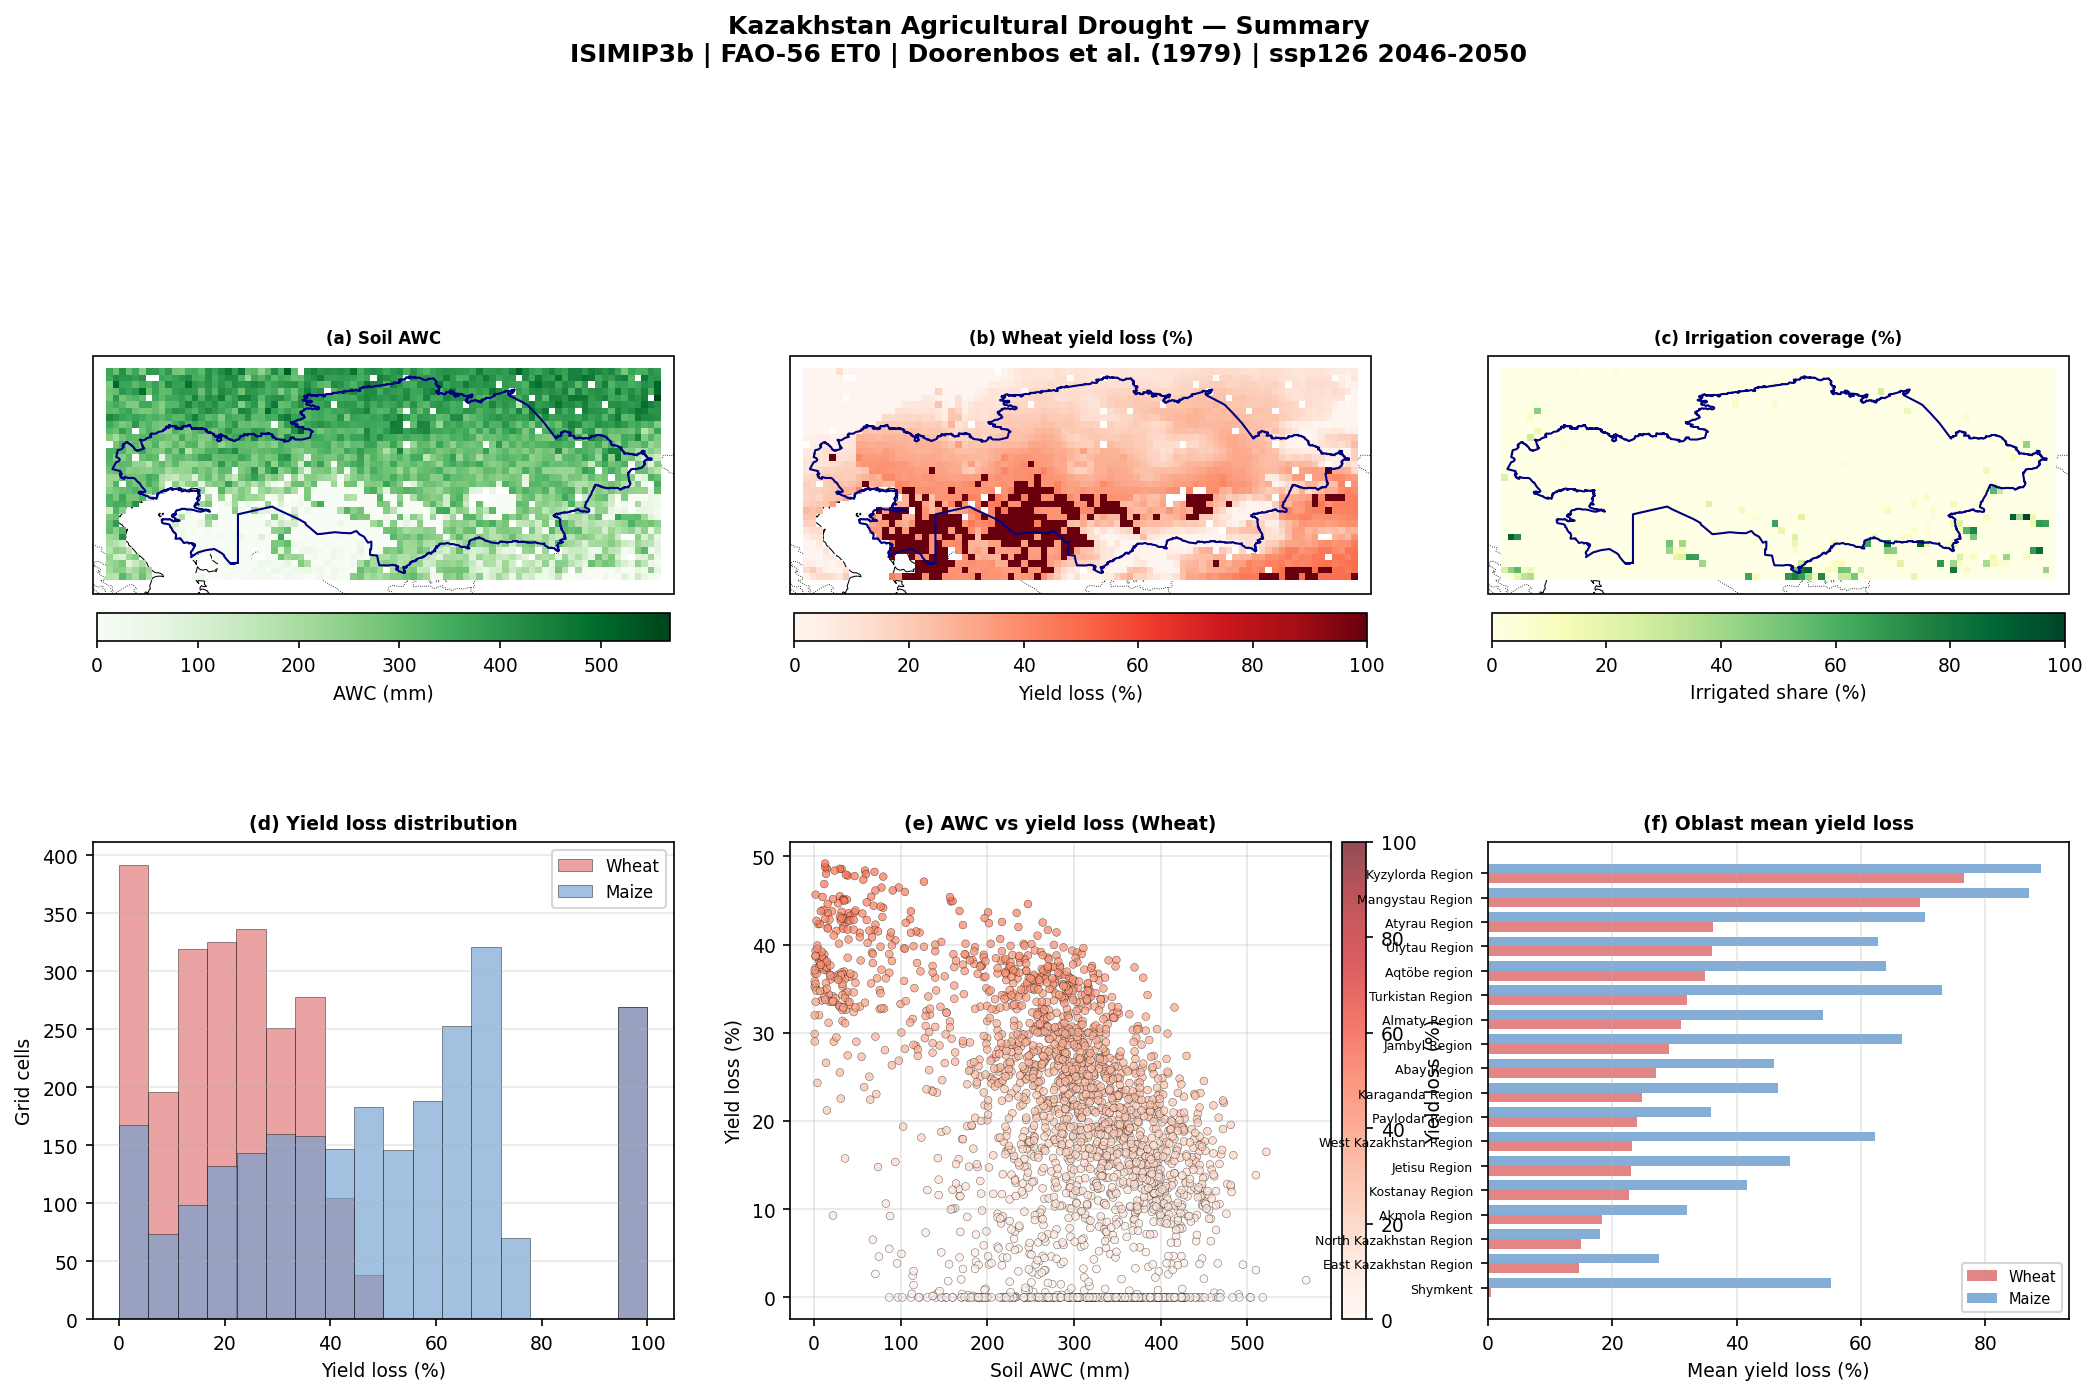

Figure 9 saved.

All figures saved to: report_figures\agricultural_drought


In [12]:
fig = plt.figure(figsize=(17, 10))
gs  = GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.2)

# Each spatial panel is added individually with its own projection
# — no plt.subplots conflict with fig.add_subplot

# (a) AWC
axA = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
setup_ax(axA, '(a) Soil AWC')
if awc_arr is not None:
    imA = imshow_kaz(axA, awc_arr, 'Greens', 0, np.nanmax(awc_arr))
    draw_boundary(axA)
    plt.colorbar(imA, ax=axA, orientation='horizontal', fraction=0.06, pad=0.04,
                 label='AWC (mm)')

# (b) Primary crop yield loss
axB = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
setup_ax(axB, f'(b) {crop_list[0].title()} yield loss (%)')
imB = imshow_kaz(axB, yield_loss[:, :, 0], 'Reds', 0, 100)
draw_boundary(axB)
plt.colorbar(imB, ax=axB, orientation='horizontal', fraction=0.06, pad=0.04,
             label='Yield loss (%)')

# (c) Irrigation share
axC = fig.add_subplot(gs[0, 2], projection=ccrs.PlateCarree())
setup_ax(axC, '(c) Irrigation coverage (%)')
if irr_share is not None:
    imC = imshow_kaz(axC, irr_share, 'YlGn', 0, 100)
    draw_boundary(axC)
    plt.colorbar(imC, ax=axC, orientation='horizontal', fraction=0.06, pad=0.04,
                 label='Irrigated share (%)')

# (d) Yield loss histogram
axD = fig.add_subplot(gs[1, 0])
for a, crop in enumerate(crop_list):
    vals = yield_loss[:, :, a].ravel()
    vals = vals[np.isfinite(vals)]
    axD.hist(vals, bins=18, alpha=0.65, label=crop.title(),
             color=clrs[a % len(clrs)], edgecolor='black', linewidth=0.3)
axD.set_xlabel('Yield loss (%)')
axD.set_ylabel('Grid cells')
axD.set_title('(d) Yield loss distribution', fontweight='bold')
axD.legend(fontsize=8)
axD.grid(axis='y', alpha=0.3)

# (e) Yield loss vs AWC scatter (primary crop)
axE = fig.add_subplot(gs[1, 1])
if awc_arr is not None:
    yl_f  = yield_loss[:, :, 0].ravel()
    awc_f = awc_arr.ravel()
    m     = np.isfinite(yl_f) & np.isfinite(awc_f) & (awc_f > 0)
    sc = axE.scatter(awc_f[m], yl_f[m], c=yl_f[m], cmap='Reds', vmin=0, vmax=100,
                     s=14, alpha=0.7, edgecolors='black', linewidths=0.2)
    plt.colorbar(sc, ax=axE, label='Yield loss (%)', fraction=0.05, pad=0.02)
axE.set_xlabel('Soil AWC (mm)')
axE.set_ylabel('Yield loss (%)')
axE.set_title(f'(e) AWC vs yield loss ({crop_list[0].title()})', fontweight='bold')
axE.grid(alpha=0.3)

# (f) Oblast mean yield loss
axF = fig.add_subplot(gs[1, 2])
for a, crop in enumerate(crop_list):
    offset = (a - (n_crops - 1) / 2) * (0.8 / n_crops)
    axF.barh(np.arange(len(ob_mean)) + offset, ob_mean[crop],
             height=0.8 / n_crops, color=clrs[a % len(clrs)],
             label=crop.title(), alpha=0.85)
axF.set_yticks(np.arange(len(ob_mean)))
axF.set_yticklabels(ob_mean.index, fontsize=6)
axF.set_xlabel('Mean yield loss (%)')
axF.set_title('(f) Oblast mean yield loss', fontweight='bold')
axF.legend(fontsize=7)
axF.grid(axis='x', alpha=0.3)

fig.suptitle(
    f'Kazakhstan Agricultural Drought — Summary\n'
    f'ISIMIP3b | FAO-56 ET0 | Doorenbos et al. (1979) | {rcp_label} {ystart}-{yend}',
    fontsize=12, fontweight='bold'
)
plt.savefig(FIG_DIR / 'fig09_summary_infographic.png', bbox_inches='tight', dpi=200)
plt.show()
print('Figure 9 saved.')
print(f'\nAll figures saved to: {FIG_DIR}')